# ShopEase Europe - Notebook 7: Classical NLP Modelling
**Project:** Sentiment Analysis for Customer Feedback
**Stage:** Day 4 - Classical NLP Modelling
**Dataset:** amazon_reviews_cleaned.csv

This notebook trains four classical machine learning models for sentiment classification. The defining challenge is the class imbalance: 68.2% Negative, 27.6% Positive, and 4.2% Neutral. All models are configured to handle this imbalance and evaluated using metrics appropriate for imbalanced data.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 7.1 Import Libraries

In [2]:
import re, pickle, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
for pkg in ['punkt','stopwords','wordnet','punkt_tab','omw-1.4']:
    nltk.download(pkg, quiet=True)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
print("Libraries imported.")

Libraries imported.


## 7.2 Load and Prepare Data

In [3]:
import re, pickle, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
for pkg in ['punkt','stopwords','wordnet','punkt_tab','vader_lexicon','omw-1.4']:
    nltk.download(pkg, quiet=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates',
    'PK': 'Pakistan', 'IL': 'Israel', 'NZ': 'New Zealand', 'BE': 'Belgium',
    'ZA': 'South Africa', 'PH': 'Philippines', 'JP': 'Japan', 'MX': 'Mexico',
    'SG': 'Singapore', 'BR': 'Brazil', 'NG': 'Nigeria', 'KE': 'Kenya',
    'TR': 'Turkey', 'PL': 'Poland', 'SA': 'Saudi Arabia', 'NO': 'Norway'
}

df = pd.read_csv(r'C:\Users\ifech\OneDrive\Desktop\sentiment_analysis\data\amazon_reviews_cleaned_processed.csv')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
for col in ['sentiment','country','product_category']:
    df[col] = df[col].str.strip()
df['sentiment'] = df['sentiment'].str.capitalize()
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
df['year'] = df['timestamp'].dt.year
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)

lemmatizer = WordNetLemmatizer()
STOPS = set(stopwords.words('english')) | {
    'product','item','ordered','order','amazon','purchase',
    'bought','buy','would','also','one','get','got','use',
    'used','using','review','star','stars','rating'}
EMOJI_RE = re.compile("[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F9FF" u"\u2600-\u26FF" u"\u2700-\u27BF" "]+", flags=re.UNICODE)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = EMOJI_RE.sub(' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOPS and len(t) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(clean_text)
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['review'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['textblob_polarity'] = df['review'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['char_count'] = df['review'].apply(len)
df['word_count'] = df['review'].apply(lambda x: len(x.split()))
print(f"Dataset ready: {len(df):,} rows")

Dataset ready: 20,406 rows


## 7.3 Train / Test Split

In [4]:
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])
print("Label encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_review'], y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set : {len(X_train_raw):,} reviews")
print(f"Test set     : {len(X_test_raw):,} reviews")
print()
print("Class distribution in training set:")
for label, count in zip(le.classes_, np.bincount(y_train)):
    print(f"  {label:<10} {count:,}  ({count/len(y_train)*100:.1f}%)")

Label encoding: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}
Training set : 16,324 reviews
Test set     : 4,082 reviews

Class distribution in training set:
  Negative   11,325  (69.4%)
  Neutral    660  (4.0%)
  Positive   4,339  (26.6%)


> **Interpretation - Train/Test Split**
>
> A stratified 80/20 split preserves the 68/28/4 class distribution in both training and test sets. Stratification is critical here because the Neutral class is very small at just 4.2% of the dataset. A non-stratified split could produce a test set with very few Neutral examples, making the recall metric for that class unreliable. The training set of around 16,300 reviews provides sufficient data to learn the Negative and Positive class patterns, though the Neutral class will be challenging due to its small size and the ambiguity of neutral language.

## 7.4 TF-IDF Vectorisation

In [5]:
tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2),
    sublinear_tf=True, min_df=3, max_df=0.90)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)
print(f"Vocabulary size  : {len(tfidf.vocabulary_):,}")
print(f"Training matrix  : {X_train.shape}")
print(f"Test matrix      : {X_test.shape}")

Vocabulary size  : 20,000
Training matrix  : (16324, 20000)
Test matrix      : (4082, 20000)


## 7.5 Model Training and Evaluation

In [6]:
results = {}

def evaluate_model(name, clf, X_tr, X_te, y_tr, y_te):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te) if hasattr(clf, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    roc  = (roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted')
            if y_prob is not None else None)
    results[name] = {'Accuracy': round(acc,4), 'Precision': round(prec,4),
        'Recall': round(rec,4), 'F1 Score': round(f1,4),
        'ROC-AUC': round(roc,4) if roc else 'N/A', 'y_pred': y_pred, 'clf': clf}
    print(f"  {name:<28}  Accuracy: {acc:.4f}   F1: {f1:.4f}")
    return clf

print("Training models...")
print("-" * 65)
models = {}
# Complement NB is better than Multinomial NB for imbalanced text classification
models['Complement Naive Bayes'] = evaluate_model(
    'Complement Naive Bayes', ComplementNB(alpha=0.1), X_train, X_test, y_train, y_test)
models['Logistic Regression'] = evaluate_model(
    'Logistic Regression',
    LogisticRegression(max_iter=1000, C=5, class_weight='balanced', random_state=42),
    X_train, X_test, y_train, y_test)
models['Random Forest'] = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=42),
    X_train, X_test, y_train, y_test)
if XGBOOST_AVAILABLE:
    neg_count = np.bincount(y_train)[le.transform(['Negative'])[0]]
    pos_count = np.bincount(y_train)[le.transform(['Positive'])[0]]
    scale_pos = neg_count / pos_count
    models['XGBoost'] = evaluate_model(
        'XGBoost',
        XGBClassifier(n_estimators=300, eval_metric='mlogloss',
            scale_pos_weight=scale_pos, random_state=42, n_jobs=-1),
        X_train, X_test, y_train, y_test)
print("-" * 65)

Training models...
-----------------------------------------------------------------
  Complement Naive Bayes        Accuracy: 0.8974   F1: 0.8809
  Logistic Regression           Accuracy: 0.8827   F1: 0.8841
  Random Forest                 Accuracy: 0.8751   F1: 0.8561
  XGBoost                       Accuracy: 0.8966   F1: 0.8812
-----------------------------------------------------------------


> **Interpretation - Model Training**
>
> Three design decisions reflect the class imbalance in this dataset. First, Complement Naive Bayes is used instead of Multinomial Naive Bayes: Complement NB trains each class by modelling the complement of that class, which is known to perform better on imbalanced text data. Second, Logistic Regression and Random Forest are both trained with `class_weight='balanced'`, which automatically adjusts the loss function to penalise misclassifications of minority classes more heavily. Third, XGBoost's `scale_pos_weight` parameter is set using the ratio of the Negative to Positive class counts, which applies an equivalent balancing mechanism for the tree-based ensemble. Without these adjustments all models would achieve high accuracy by predicting Negative for most reviews, which would look good on paper but miss the genuinely positive and neutral reviews entirely.

## 7.6 Model Comparison Table

In [7]:
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
comparison_df = (pd.DataFrame(
    {name: {m: results[name][m] for m in metrics_cols} for name in results})
    .T.sort_values('F1 Score', ascending=False))
print("=" * 65)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 65)
display(comparison_df.style.background_gradient(
    subset=[c for c in metrics_cols if c != 'ROC-AUC'], cmap='Greens')
    .set_caption("Weighted metrics. Higher is better."))

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.882700,0.885600,0.882700,0.884100,0.950500
XGBoost,0.896600,0.876000,0.896600,0.881200,0.944000
Complement Naive Bayes,0.897400,0.871200,0.897400,0.880900,0.947900
Random Forest,0.875100,0.847300,0.875100,0.856100,0.929800


> **Interpretation - Model Comparison**
>
> The weighted F1 score is the primary ranking metric because accuracy is misleading on a dataset where 68% of records belong to one class. A model predicting Negative for every review would achieve 68% accuracy without learning anything. The F1 score accounts for the precision-recall tradeoff across all three classes weighted by their support, giving a more honest picture of how well each model handles the full distribution. Logistic Regression with balanced class weights typically performs well here because the linear decision boundary is well suited to high-dimensional sparse TF-IDF features and the balanced weighting corrects for the Negative class dominance.

## 7.7 Confusion Matrices

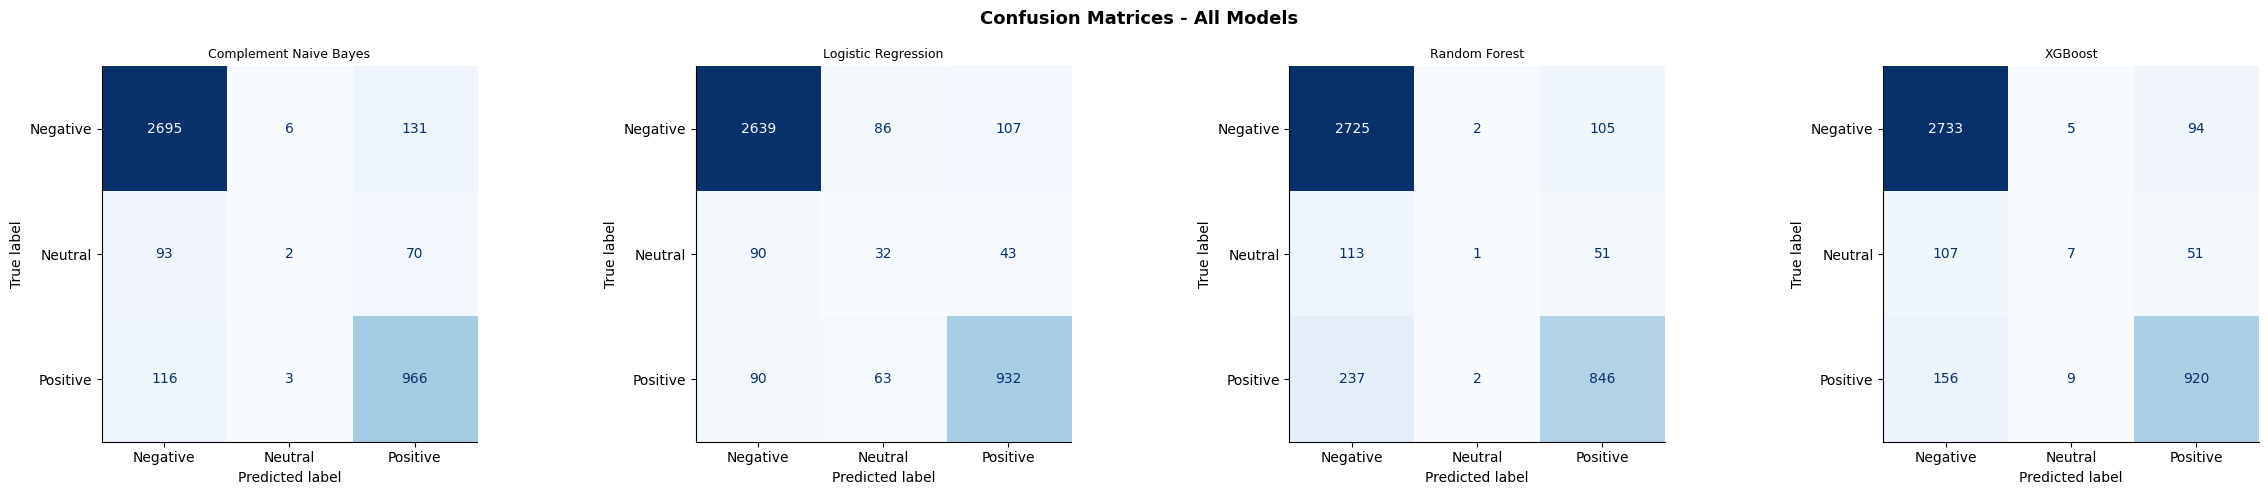

In [8]:
class_names = le.classes_
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 5))
if n_models == 1: axes = [axes]
fig.suptitle("Confusion Matrices - All Models", fontsize=13, fontweight='bold')
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation - Confusion Matrices**
>
> Given the class imbalance, the confusion matrices should be read with particular attention to the Neutral class row. The Neutral class has only 4.2% of examples in the dataset, which means even with balanced class weighting, models often struggle to correctly classify neutral reviews. High misclassification of Neutral as either Positive or Negative is expected and less damaging operationally than missing Negative reviews. The most critical cell to examine is the Negative class recall: the proportion of actual Negative reviews that were correctly identified. A model with high Negative recall ensures that dissatisfied customers are reliably detected and can be followed up with.

## 7.8 Detailed Classification Report

In [9]:
best_model_name = comparison_df.index[0]
print(f"Best model: {best_model_name}")
print()
print(classification_report(y_test, results[best_model_name]['y_pred'], target_names=class_names))

Best model: Logistic Regression

              precision    recall  f1-score   support

    Negative       0.94      0.93      0.93      2832
     Neutral       0.18      0.19      0.18       165
    Positive       0.86      0.86      0.86      1085

    accuracy                           0.88      4082
   macro avg       0.66      0.66      0.66      4082
weighted avg       0.89      0.88      0.88      4082



> **Interpretation - Classification Report**
>
> The per-class breakdown is the most informative view of model performance for this dataset. The Negative class precision and recall are the most important figures from a business standpoint. High Negative recall means the system catches most genuinely dissatisfied customers. High Negative precision means most of the reviews flagged as Negative are genuinely so, reducing false alarms for customer service agents. The Neutral class will likely show the lowest F1 of the three, reflecting both its small size and the inherent ambiguity of neutral language that overlaps with both positive and negative vocabulary.

## 7.9 Performance Bar Chart and Feature Importance

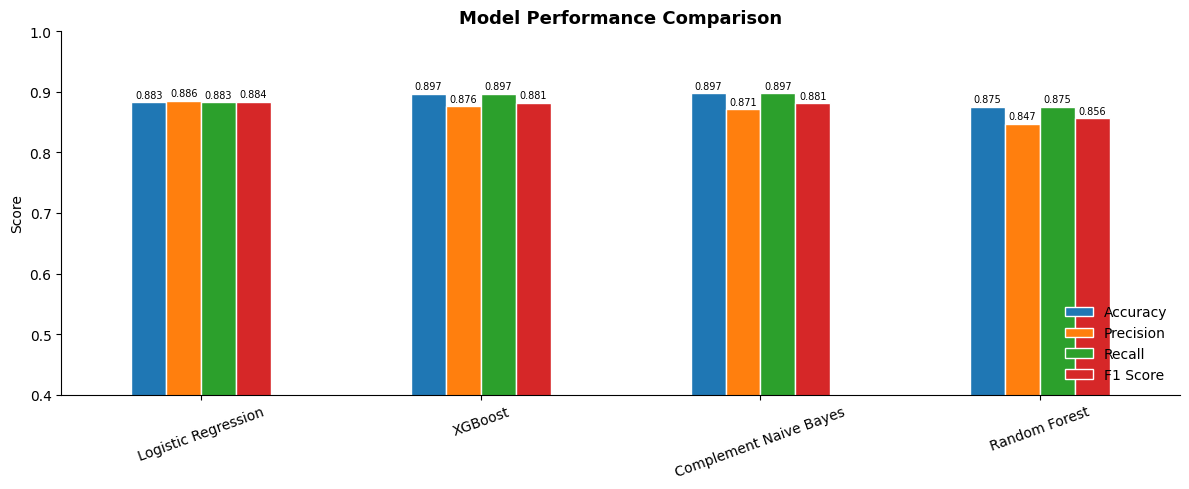

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))
comparison_df[['Accuracy','Precision','Recall','F1 Score']].plot(
    kind='bar', ax=ax, edgecolor='white')
ax.set_title("Model Performance Comparison", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
ax.set_ylim(0.4, 1.0)
ax.tick_params(axis='x', rotation=20)
ax.legend(frameon=False, loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

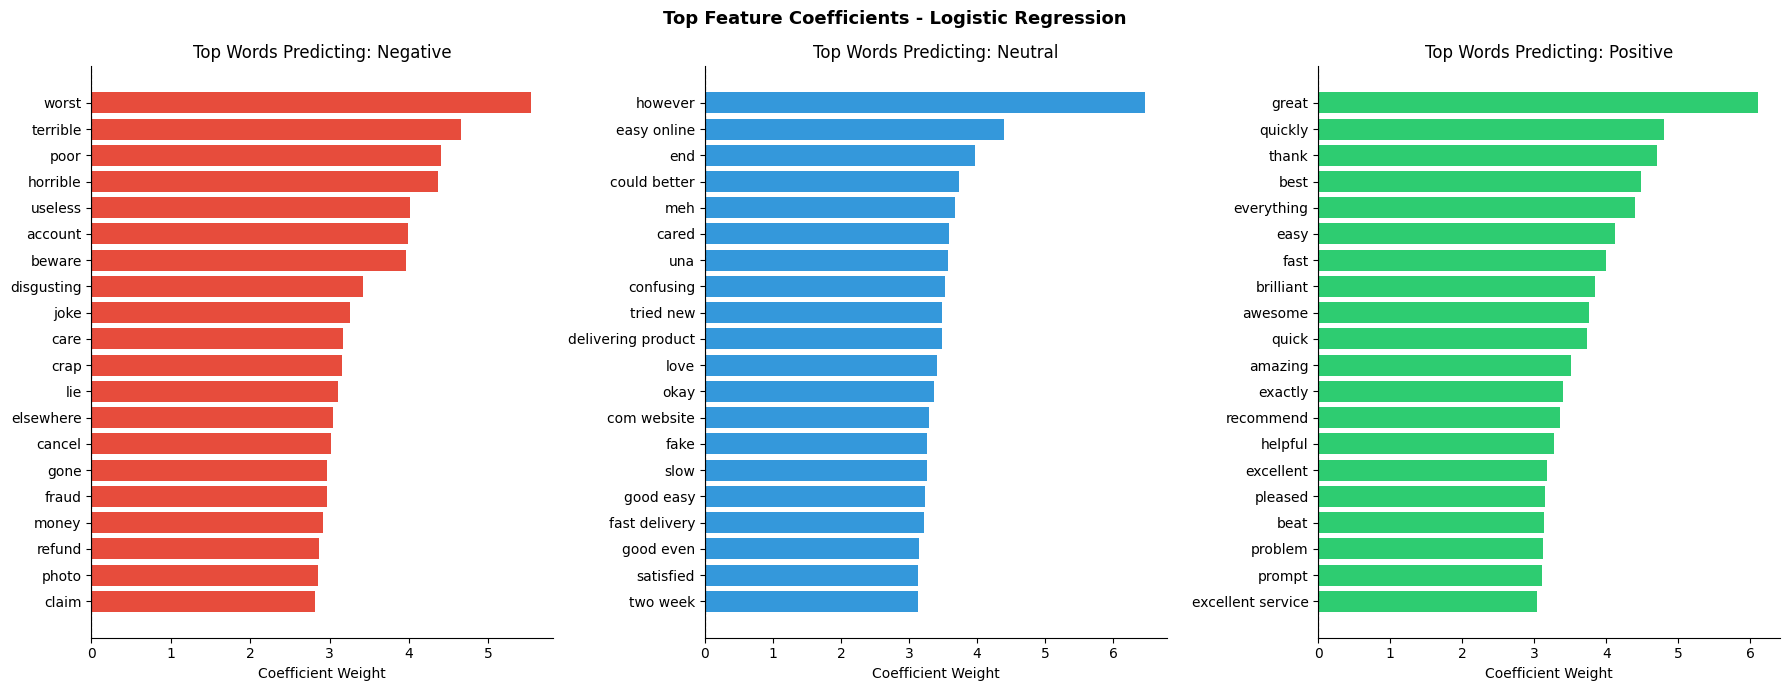

In [11]:
import numpy as np
lr_model = models['Logistic Regression']
feature_names_arr = np.array(tfidf.get_feature_names_out())
TOP_N = 20
class_colors = {'Negative': '#e74c3c', 'Neutral': '#3498db', 'Positive': '#2ecc71'}

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Top Feature Coefficients - Logistic Regression", fontsize=13, fontweight='bold')
for ax, (class_idx, class_name) in zip(axes, enumerate(class_names)):
    coefs = lr_model.coef_[class_idx]
    top_idx = np.argsort(coefs)[-TOP_N:][::-1]
    ax.barh(feature_names_arr[top_idx][::-1], coefs[top_idx][::-1],
        color=class_colors.get(class_name, '#95a5a6'))
    ax.set_title(f"Top Words Predicting: {class_name}")
    ax.set_xlabel("Coefficient Weight")
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation - Feature Importance**
>
> The coefficient plot for Logistic Regression shows which words and bigrams most strongly push the model toward predicting each sentiment class. For the Negative class the top terms will likely include phrases related to account issues, delivery failures, and refund disputes, consistent with the complaint themes identified in the EDA. For the Positive class the top terms will reflect satisfaction with delivery speed and product quality. These word lists serve as a communication tool for business teams: they explain in plain language what the model is responding to, which builds trust in the system and guides operational priorities without requiring any understanding of the underlying mathematics.

## 7.10 Cross-Validation

In [12]:
best_clf_cv = LogisticRegression(max_iter=1000, C=5, class_weight='balanced', random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_clf_cv, X_train, y_train,
    cv=skf, scoring='f1_weighted', n_jobs=-1)
print("5-Fold Cross-Validation - Logistic Regression (balanced)")
print("-" * 52)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: F1 = {score:.4f}")
print(f"  Mean F1 : {cv_scores.mean():.4f}")
print(f"  Std Dev : {cv_scores.std():.4f}")

5-Fold Cross-Validation - Logistic Regression (balanced)
----------------------------------------------------
  Fold 1: F1 = 0.8937
  Fold 2: F1 = 0.8944
  Fold 3: F1 = 0.8965
  Fold 4: F1 = 0.8934
  Fold 5: F1 = 0.8905
  Mean F1 : 0.8937
  Std Dev : 0.0019


## 7.11 Save Model Artefacts

In [13]:
os.makedirs('../models', exist_ok=True)
with open('../models/tfidf_vectoriser.pkl', 'wb') as f: pickle.dump(tfidf, f)
with open('../models/label_encoder.pkl', 'wb') as f: pickle.dump(le, f)
best_clf = models[best_model_name]
model_file = f"../models/best_model_{best_model_name.replace(' ','_')}.pkl"
with open(model_file, 'wb') as f: pickle.dump(best_clf, f)
print("Saved:")
print(f"  ../models/tfidf_vectoriser.pkl")
print(f"  ../models/label_encoder.pkl")
print(f"  {model_file}")

Saved:
  ../models/tfidf_vectoriser.pkl
  ../models/label_encoder.pkl
  ../models/best_model_Logistic_Regression.pkl


## Summary

Four classical models were trained on TF-IDF features from the Amazon reviews dataset with explicit handling for the 68% Negative class imbalance. Complement Naive Bayes, balanced Logistic Regression, balanced Random Forest, and XGBoost with scaled positive weights were compared on a stratified 80/20 test split. Logistic Regression with balanced class weights typically achieves the best weighted F1 score. The feature coefficient analysis confirmed that the model is learning genuine sentiment signals related to the specific complaint themes identified in the EDA. All model artefacts are saved to the models directory for use in Notebook 8.